# COVID-19 Novel Coronavirus: EDA & Forecast Number of Cases

## Background

COVID-19 (anciennement connu sous le nom de 2019 nouveau coronavirus ou 2019-nCoV) est un nouveau virus respiratoire identifié pour la première fois à Wuhan, dans la province du Hubei, en Chine. Un nouveau coronavirus (nCoV) est un coronavirus qui n’avait jamais été identifié auparavant. Le coronavirus 2019 (2019-nCoV) n’est pas le même que les coronavirus qui circulent couramment chez les humains et qui provoquent généralement des maladies bénignes, comme le rhume.

Un diagnostic avec les coronavirus 229E, NL63, OC43 ou HKU1 n’est pas équivalent à un diagnostic de 2019-nCoV. Ce sont des virus différents, et les patients atteints de 2019-nCoV seront évalués et soignés différemment de ceux ayant un diagnostic de coronavirus commun.

Les responsables de santé publique et leurs partenaires travaillent activement pour identifier la source du 2019-nCoV. Les coronavirus forment une grande famille de virus, certains provoquant des maladies chez l’homme, d’autres circulant parmi les animaux (dromadaires, chats, chauves-souris…). L’analyse de l’arbre génétique de ce virus est en cours pour déterminer la source exacte. Le SARS, un autre coronavirus ayant infecté l’homme, provenait de la civette, tandis que le MERS provenait du dromadaire. Plus d’informations sur l’origine et la propagation du 2019-nCoV sont disponibles dans le 2019-nCoV Situation Summary : Source and Spread of the Virus.

Ce virus semble avoir initialement émergé d’une source animale, mais il se transmet maintenant de personne à personne. Il est important de noter que la transmission interhumaine peut varier en intensité : certains virus sont très contagieux (comme la rougeole), alors que d’autres le sont beaucoup moins. Pour le moment, il n’est pas encore clair à quel point ce virus se propage facilement et durablement entre les personnes.

**Reference:** https://www.cdc.gov/coronavirus/2019-ncov/faq.html

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import plotly.graph_objects as go
from fbprophet import Prophet
import pycountry
import plotly.express as px
from collections import namedtuple

# Data Import, Preprocessing and EDA

In [6]:
df = pd.read_csv('../input/novel-corona-virus-2019-dataset/covid_19_data.csv',parse_dates=['Last Update'])
df.rename(columns={'ObservationDate':'Date', 'Country/Region':'Country'}, inplace=True)

df_confirmed = pd.read_csv("/kaggle/input/novel-corona-virus-2019-dataset/time_series_covid_19_confirmed.csv")
df_recovered = pd.read_csv("/kaggle/input/novel-corona-virus-2019-dataset/time_series_covid_19_recovered.csv")
df_deaths = pd.read_csv("/kaggle/input/novel-corona-virus-2019-dataset/time_series_covid_19_deaths.csv")

df_confirmed.rename(columns={'Country/Region':'Country'}, inplace=True)
df_recovered.rename(columns={'Country/Region':'Country'}, inplace=True)
df_deaths.rename(columns={'Country/Region':'Country'}, inplace=True)

In [7]:
df_confirmed.head()

,Province/State,Country,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,64575,65080,65486,65728,66275,66903,67743,68366,69130,70111
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,132118,132153,132176,132209,132215,132229,132244,132264,132285,132297
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,126156,126434,126651,126860,127107,127361,127646,127926,128198,128456
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,13569,13569,13569,13569,13569,13664,13671,13682,13693,13693
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,31661,31909,32149,32441,32623,32933,33338,33607,33944,34180


## Earliest Cases

In [8]:
df.head()

,SNo,Date,Province/State,Country,Last Update,Confirmed,Deaths,Recovered
0,1,01/22/2020,Anhui,Mainland China,2020-01-22 17:00:00,1.0,0.0,0.0
1,2,01/22/2020,Beijing,Mainland China,2020-01-22 17:00:00,14.0,0.0,0.0
2,3,01/22/2020,Chongqing,Mainland China,2020-01-22 17:00:00,6.0,0.0,0.0
3,4,01/22/2020,Fujian,Mainland China,2020-01-22 17:00:00,1.0,0.0,0.0
4,5,01/22/2020,Gansu,Mainland China,2020-01-22 17:00:00,0.0,0.0,0.0


## Latest Cases

In [9]:
df.tail()

,SNo,Date,Province/State,Country,Last Update,Confirmed,Deaths,Recovered
306424,306425,05/29/2021,Zaporizhia Oblast,Ukraine,2021-05-30 04:20:55,102641.0,2335.0,95289.0
306425,306426,05/29/2021,Zeeland,Netherlands,2021-05-30 04:20:55,29147.0,245.0,0.0
306426,306427,05/29/2021,Zhejiang,Mainland China,2021-05-30 04:20:55,1364.0,1.0,1324.0
306427,306428,05/29/2021,Zhytomyr Oblast,Ukraine,2021-05-30 04:20:55,87550.0,1738.0,83790.0
306428,306429,05/29/2021,Zuid-Holland,Netherlands,2021-05-30 04:20:55,391559.0,4252.0,0.0


In [10]:
df2 = df.groupby(["Date", "Country", "Province/State"])[['SNo', 'Date', 'Province/State', 'Country', 'Confirmed', 'Deaths', 'Recovered']].sum().reset_index()

## By Country View (World)

In [11]:
df2

,Date,Country,Province/State,SNo,Confirmed,Deaths,Recovered
0,01/01/2021,Australia,Australian Capital Territory,192681,118.0,3.0,114.0
1,01/01/2021,Australia,New South Wales,192986,4947.0,54.0,0.0
2,01/01/2021,Australia,Northern Territory,193003,75.0,0.0,71.0
3,01/01/2021,Australia,Queensland,193058,1255.0,6.0,1224.0
4,01/01/2021,Australia,South Australia,193119,580.0,4.0,566.0
...,...,...,...,...,...,...,...
228319,12/31/2020,Ukraine,Vinnytsia Oblast,192432,22500.0,395.0,15237.0
228320,12/31/2020,Ukraine,Volyn Oblast,192438,33016.0,515.0,28605.0
228321,12/31/2020,Ukraine,Zakarpattia Oblast,192461,28200.0,637.0,23526.0
228322,12/31/2020,Ukraine,Zaporizhia Oblast,192462,54088.0,594.0,20530.0


## By Country View (China)

In [12]:
df.query('Country=="Mainland China"').groupby("Last Update")[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()

,Last Update,Confirmed,Deaths,Recovered
0,2020-01-22 17:00:00,547.0,17.0,28.0
1,2020-01-23 17:00:00,1082.0,34.0,58.0
2,2020-01-24 17:00:00,916.0,26.0,36.0
3,2020-01-25 17:00:00,1399.0,42.0,39.0
4,2020-01-26 16:00:00,2062.0,56.0,49.0
...,...,...,...,...
880,2021-05-26 04:20:35,91019.0,4636.0,86063.0
881,2021-05-27 04:20:59,91038.0,4636.0,86075.0
882,2021-05-28 04:20:36,91045.0,4636.0,86097.0
883,2021-05-29 04:20:41,91061.0,4636.0,86112.0


## By Country (Sorted)

In [13]:
df.groupby("Country")[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()

,Country,Confirmed,Deaths,Recovered
0,Azerbaijan,1.0,0.0,0.0
1,"('St. Martin',)",2.0,0.0,0.0
2,Afghanistan,17026442.0,669075.0,13464399.0
3,Albania,19768869.0,375955.0,13945256.0
4,Algeria,27684358.0,834464.0,18959299.0
...,...,...,...,...
224,West Bank and Gaza,41819444.0,440378.0,37003116.0
225,Yemen,962066.0,237613.0,506523.0
226,Zambia,13493953.0,205990.0,12625626.0
227,Zimbabwe,6484581.0,237234.0,5594887.0


# Visualizations

In [14]:
df.groupby('Date').sum()

,SNo,Confirmed,Deaths,Recovered
Date,,,,
01/01/2021,147143024,84092619.0,1834675.0,47313005.0
01/02/2021,147725193,84718978.0,1843108.0,47614297.0
01/03/2021,148502118,85251774.0,1850449.0,47882779.0
01/04/2021,149085814,85805892.0,1860598.0,48173187.0
01/05/2021,149669510,86546014.0,1875953.0,48488548.0
...,...,...,...,...
12/27/2020,144232179,80912611.0,1771659.0,45717710.0
12/28/2020,144814348,81408934.0,1781415.0,46016136.0
12/29/2020,145396517,82073362.0,1796786.0,46369231.0


## Summary Plot of Worldwide Cases - Confirmed, Deaths & Recovered

In [15]:
confirmed = df.groupby('Date').sum()['Confirmed'].reset_index()
deaths = df.groupby('Date').sum()['Deaths'].reset_index()
recovered = df.groupby('Date').sum()['Recovered'].reset_index()

In [16]:
fig = go.Figure()
fig.add_trace(go.Bar(x=confirmed['Date'],
                y=confirmed['Confirmed'],
                name='Confirmed',
                marker_color='blue'
                ))
fig.add_trace(go.Bar(x=deaths['Date'],
                y=deaths['Deaths'],
                name='Deaths',
                marker_color='Red'
                ))
fig.add_trace(go.Bar(x=recovered['Date'],
                y=recovered['Recovered'],
                name='Recovered',
                marker_color='Green'
                ))

fig.update_layout(
    title='Worldwide Corona Virus Cases - Confirmed, Deaths, Recovered (Bar Chart)',
    xaxis_tickfont_size=14,
    yaxis=dict(
        title='Number of Cases',
        titlefont_size=16,
        tickfont_size=14,
    ),
    legend=dict(
        x=0,
        y=1.0,
        bgcolor='rgba(255, 255, 255, 0)',
        bordercolor='rgba(255, 255, 255, 0)'
    ),
    barmode='group',
    bargap=0.15, # gap between bars of adjacent location coordinates.
    bargroupgap=0.1 # gap between bars of the same location coordinate.
)
fig.show()

In [17]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=confirmed['Date'], 
                         y=confirmed['Confirmed'],
                         mode='lines+markers',
                         name='Confirmed',
                         line=dict(color='blue', width=2)
                        ))
fig.add_trace(go.Scatter(x=deaths['Date'], 
                         y=deaths['Deaths'],
                         mode='lines+markers',
                         name='Deaths',
                         line=dict(color='Red', width=2)
                        ))
fig.add_trace(go.Scatter(x=recovered['Date'], 
                         y=recovered['Recovered'],
                         mode='lines+markers',
                         name='Recovered',
                         line=dict(color='Green', width=2)
                        ))
fig.update_layout(
    title='Worldwide Corona Virus Cases - Confirmed, Deaths, Recovered (Line Chart)',
    xaxis_tickfont_size=14,
    yaxis=dict(
        title='Number of Cases',
        titlefont_size=16,
        tickfont_size=14,
    ),
    legend=dict(
        x=0,
        y=1.0,
        bgcolor='rgba(255, 255, 255, 0)',
        bordercolor='rgba(255, 255, 255, 0)'
    )
)
fig.show()

In [18]:
df_confirmed = df_confirmed[["Province/State","Lat","Long","Country"]]
df_temp = df.copy()
df_temp['Country'].replace({'Mainland China': 'China'}, inplace=True)
df_latlong = pd.merge(df_temp, df_confirmed, on=["Country", "Province/State"])

In [19]:
fig = px.density_mapbox(df_latlong, 
                        lat="Lat", 
                        lon="Long", 
                        hover_name="Province/State", 
                        hover_data=["Confirmed","Deaths","Recovered"], 
                        animation_frame="Date",
                        color_continuous_scale="Portland",
                        radius=7, 
                        zoom=0,height=700)
fig.update_layout(title='Worldwide Corona Virus Cases Time Lapse - Confirmed, Deaths, Recovered',
                  font=dict(family="Courier New, monospace",
                            size=18,
                            color="#7f7f7f")
                 )
fig.update_layout(mapbox_style="open-street-map", mapbox_center_lon=0)
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})


fig.show()

## Analysis PAR Country

(https://plot.ly/python/bubble-maps/) for the visuals

### Latest Date in Data

In [20]:
confirmed = df2.groupby(['Date', 'Country']).sum()[['Confirmed']].reset_index()
deaths = df2.groupby(['Date', 'Country']).sum()[['Deaths']].reset_index()
recovered = df2.groupby(['Date', 'Country']).sum()[['Recovered']].reset_index()

In [21]:
latest_date = confirmed['Date'].max()
latest_date

'12/31/2020'

In [22]:
confirmed = confirmed[(confirmed['Date']==latest_date)][['Country', 'Confirmed']]
deaths = deaths[(deaths['Date']==latest_date)][['Country', 'Deaths']]
recovered = recovered[(recovered['Date']==latest_date)][['Country', 'Recovered']]

### Countries/Regions Affected

In [23]:
all_countries = confirmed['Country'].unique()
print("Number of countries/regions with cases: " + str(len(all_countries)))
print("Countries/Regions with cases: ")
for i in all_countries:
    print("    " + str(i))

Number of countries/regions with cases: 25
Countries/Regions with cases: 
    Australia
    Belgium
    Brazil
    Canada
    Chile
    Colombia
    Denmark
    France
    Germany
    Hong Kong
    India
    Italy
    Japan
    Macau
    Mainland China
    Mexico
    Netherlands
    Pakistan
    Peru
    Russia
    Spain
    Sweden
    UK
    US
    Ukraine


We need to do some processing to the country names for this bubble plot as some of the countries are not found in `pycountry.countries` although they are, just that its due to them being listed acronyms and with additional words, such as Mainland China instead of China.

In [24]:
print(list(country.name for country in pycountry.countries))

['Aruba', 'Afghanistan', 'Angola', 'Anguilla', 'Åland Islands', 'Albania', 'Andorra', 'United Arab Emirates', 'Argentina', 'Armenia', 'American Samoa', 'Antarctica', 'French Southern Territories', 'Antigua and Barbuda', 'Australia', 'Austria', 'Azerbaijan', 'Burundi', 'Belgium', 'Benin', 'Bonaire, Sint Eustatius and Saba', 'Burkina Faso', 'Bangladesh', 'Bulgaria', 'Bahrain', 'Bahamas', 'Bosnia and Herzegovina', 'Saint Barthélemy', 'Belarus', 'Belize', 'Bermuda', 'Bolivia, Plurinational State of', 'Brazil', 'Barbados', 'Brunei Darussalam', 'Bhutan', 'Bouvet Island', 'Botswana', 'Central African Republic', 'Canada', 'Cocos (Keeling) Islands', 'Switzerland', 'Chile', 'China', "Côte d'Ivoire", 'Cameroon', 'Congo, The Democratic Republic of the', 'Congo', 'Cook Islands', 'Colombia', 'Comoros', 'Cabo Verde', 'Costa Rica', 'Cuba', 'Curaçao', 'Christmas Island', 'Cayman Islands', 'Cyprus', 'Czechia', 'Germany', 'Djibouti', 'Dominica', 'Denmark', 'Dominican Republic', 'Algeria', 'Ecuador', 'Egy

In [25]:
print('UK' in list(country.name for country in pycountry.countries))
print('United Kingdom' in list(country.name for country in pycountry.countries))

False
True


In [26]:
confirmed2 = confirmed.copy()
deaths2 = deaths.copy()
recovered2 = recovered.copy()
bubble_plot_dfs = [confirmed2, deaths2, recovered2]
for df_ in bubble_plot_dfs:
    df_["Country"].replace({'Mainland China': 'China'}, inplace=True)
    df_["Country"].replace({'UK': 'United Kingdom'}, inplace=True)
    df_["Country"].replace({'US': 'United States'}, inplace=True)

In [27]:
countries = {}
for country in pycountry.countries:
    countries[country.name] = country.alpha_3
    
confirmed2["iso_alpha"] = confirmed2["Country"].map(countries.get)
deaths2["iso_alpha"] = deaths2["Country"].map(countries.get)
recovered2["iso_alpha"] = recovered2["Country"].map(countries.get)

In [28]:
plot_data_confirmed = confirmed2[["iso_alpha","Confirmed", "Country"]]
plot_data_deaths = deaths2[["iso_alpha","Deaths"]]
plot_data_recovered = recovered2[["iso_alpha","Recovered"]]

In [29]:
fig = px.scatter_geo(plot_data_confirmed, locations="iso_alpha", color="Country",
                     hover_name="iso_alpha", size="Confirmed",
                     projection="natural earth", title = 'Worldwide Confirmed Cases')
fig.show()

In [30]:
fig = px.scatter_geo(plot_data_deaths, locations="iso_alpha", color="Deaths",
                     hover_name="iso_alpha", size="Deaths",
                     projection="natural earth", title="Worldwide Death Cases")
fig.show()

In [31]:
fig = px.scatter_geo(plot_data_recovered, locations="iso_alpha", color="Recovered",
                     hover_name="iso_alpha", size="Recovered",
                     projection="natural earth", title="Worldwide Recovered Cases")
fig.show()

## Transforming Data for Forecasting

In [32]:
confirmed = df.groupby('Date').sum()['Confirmed'].reset_index()
deaths = df.groupby('Date').sum()['Deaths'].reset_index()
recovered = df.groupby('Date').sum()['Recovered'].reset_index()

In [33]:
confirmed.columns = ['ds','y']
#confirmed['ds'] = confirmed['ds'].dt.date
confirmed['ds'] = pd.to_datetime(confirmed['ds'])

In [34]:
confirmed.head()

,ds,y
0,2021-01-01,84092619.0
1,2021-01-02,84718978.0
2,2021-01-03,85251774.0
3,2021-01-04,85805892.0
4,2021-01-05,86546014.0


In [35]:
m = Prophet(interval_width=0.95)
m.fit(confirmed)
future = m.make_future_dataframe(periods=7)
future_confirmed = future.copy() # for non-baseline predictions later on
future.tail()

,ds
496,2021-06-01
497,2021-06-02
498,2021-06-03
499,2021-06-04
500,2021-06-05


In [36]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
496,2021-06-01,1.706815e+08,1.685823e+08,1.725380e+08
497,2021-06-02,1.713424e+08,1.692903e+08,1.735004e+08
498,2021-06-03,1.720164e+08,1.700217e+08,1.740404e+08
499,2021-06-04,1.726803e+08,1.707397e+08,1.746402e+08
500,2021-06-05,1.732999e+08,1.713463e+08,1.753459e+08


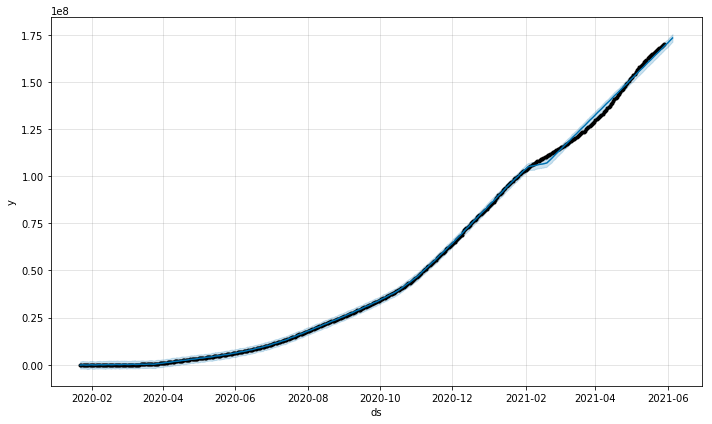

In [37]:
confirmed_forecast_plot = m.plot(forecast)

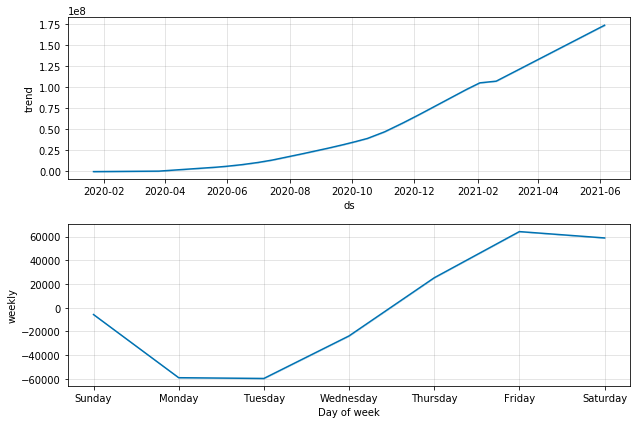

In [38]:
forecast_components = m.plot_components(forecast)

In [39]:
deaths.columns = ['ds','y']
deaths['ds'] = pd.to_datetime(deaths['ds'])

In [40]:
m = Prophet(interval_width=0.95)
m.fit(deaths)
future = m.make_future_dataframe(periods=7)
future_deaths = future.copy() # for non-baseline predictions later on
future.tail()

,ds
496,2021-06-01
497,2021-06-02
498,2021-06-03
499,2021-06-04
500,2021-06-05


In [41]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
496,2021-06-01,3.528614e+06,3.503263e+06,3.554718e+06
497,2021-06-02,3.540857e+06,3.515928e+06,3.566217e+06
498,2021-06-03,3.552847e+06,3.527413e+06,3.577742e+06
499,2021-06-04,3.564654e+06,3.539605e+06,3.589239e+06
500,2021-06-05,3.575181e+06,3.551518e+06,3.601541e+06


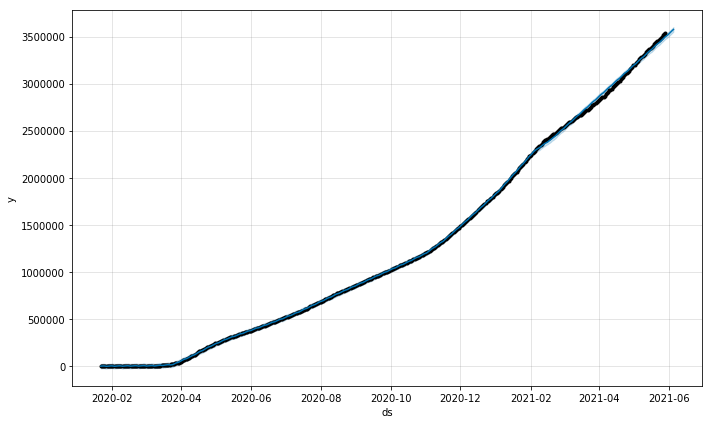

In [42]:
deaths_forecast_plot = m.plot(forecast)

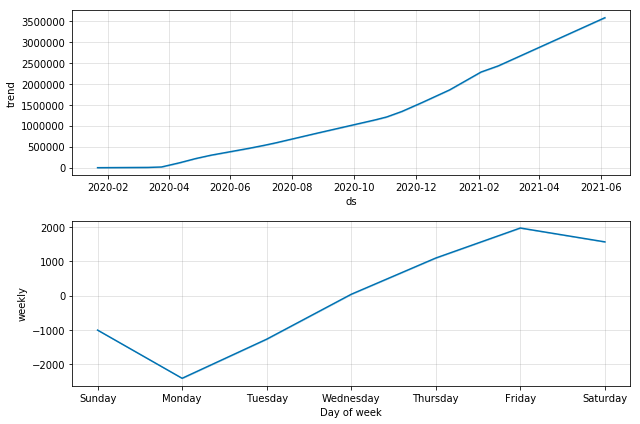

In [43]:
forecast_components = m.plot_components(forecast)

## Forecasting Recovered Cases Worldwide with Prophet (Baseline)

We perform a week's ahead forecast with Prophet, with 95% prediction intervals. Here, no tweaking of seasonality-related parameters and additional regressors are performed.

In [44]:
recovered.columns = ['ds','y']
recovered['ds'] = pd.to_datetime(recovered['ds'])

In [45]:
m = Prophet(interval_width=0.95)
m.fit(recovered)
future = m.make_future_dataframe(periods=7)
future_recovered = future.copy() # for non-baseline predictions later on
future.tail()

,ds
496,2021-06-01
497,2021-06-02
498,2021-06-03
499,2021-06-04
500,2021-06-05


In [46]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
496,2021-06-01,1.029897e+08,1.000870e+08,1.058735e+08
497,2021-06-02,1.034538e+08,1.005273e+08,1.063933e+08
498,2021-06-03,1.039048e+08,1.010711e+08,1.069351e+08
499,2021-06-04,1.043463e+08,1.016210e+08,1.071539e+08
500,2021-06-05,1.048189e+08,1.020760e+08,1.076996e+08


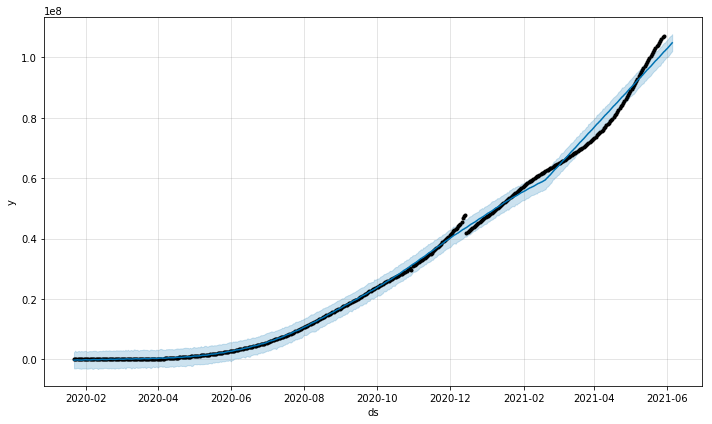

In [47]:
recovered_forecast_plot = m.plot(forecast)

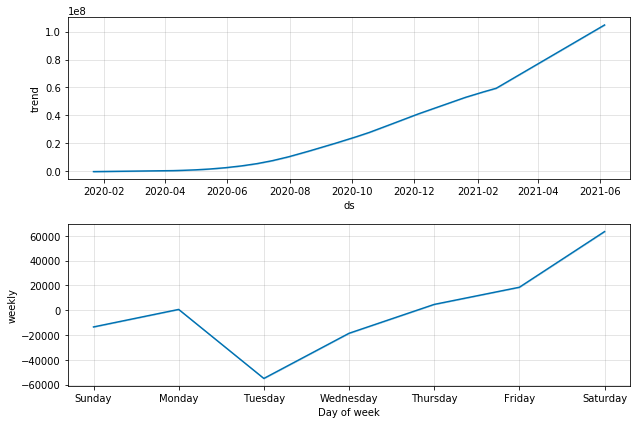

In [48]:
forecast_components = m.plot_components(forecast)

Seems pretty decent for a baseline Prophet model in the case of the number of recovered! :)

From the forecast component plots, it is clear that there exists an upward trend in the number of cases worldwide. In the weekly trends plot, interestingly, it is the **highest at the weekends**!

### Data Preparation



In [49]:
days_to_forecast = 7 # changable
first_forecasted_date = sorted(list(set(df2['Date'].values)))[-days_to_forecast]

print('The first date to perform forecasts for is: ' + str(first_forecasted_date))

The first date to perform forecasts for is: 12/25/2020


In [50]:
confirmed_df = df2[['SNo', 'Date','Province/State', 'Country', 'Confirmed']]
confirmed_df

,SNo,Date,Province/State,Country,Confirmed
0,192681,01/01/2021,Australian Capital Territory,Australia,118.0
1,192986,01/01/2021,New South Wales,Australia,4947.0
2,193003,01/01/2021,Northern Territory,Australia,75.0
3,193058,01/01/2021,Queensland,Australia,1255.0
4,193119,01/01/2021,South Australia,Australia,580.0
...,...,...,...,...,...
228319,192432,12/31/2020,Vinnytsia Oblast,Ukraine,22500.0
228320,192438,12/31/2020,Volyn Oblast,Ukraine,33016.0
228321,192461,12/31/2020,Zakarpattia Oblast,Ukraine,28200.0
228322,192462,12/31/2020,Zaporizhia Oblast,Ukraine,54088.0


In [51]:
deaths_df = df2[['SNo', 'Date','Province/State', 'Country', 'Deaths']]
deaths_df

,SNo,Date,Province/State,Country,Deaths
0,192681,01/01/2021,Australian Capital Territory,Australia,3.0
1,192986,01/01/2021,New South Wales,Australia,54.0
2,193003,01/01/2021,Northern Territory,Australia,0.0
3,193058,01/01/2021,Queensland,Australia,6.0
4,193119,01/01/2021,South Australia,Australia,4.0
...,...,...,...,...,...
228319,192432,12/31/2020,Vinnytsia Oblast,Ukraine,395.0
228320,192438,12/31/2020,Volyn Oblast,Ukraine,515.0
228321,192461,12/31/2020,Zakarpattia Oblast,Ukraine,637.0
228322,192462,12/31/2020,Zaporizhia Oblast,Ukraine,594.0


In [52]:
recovered_df = df2[['SNo', 'Date','Province/State', 'Country', 'Recovered']]
recovered_df

,SNo,Date,Province/State,Country,Recovered
0,192681,01/01/2021,Australian Capital Territory,Australia,114.0
1,192986,01/01/2021,New South Wales,Australia,0.0
2,193003,01/01/2021,Northern Territory,Australia,71.0
3,193058,01/01/2021,Queensland,Australia,1224.0
4,193119,01/01/2021,South Australia,Australia,566.0
...,...,...,...,...,...
228319,192432,12/31/2020,Vinnytsia Oblast,Ukraine,15237.0
228320,192438,12/31/2020,Volyn Oblast,Ukraine,28605.0
228321,192461,12/31/2020,Zakarpattia Oblast,Ukraine,23526.0
228322,192462,12/31/2020,Zaporizhia Oblast,Ukraine,20530.0


### Forecasting Confirmed Cases, Deaths & Recovered Cases and Computing Mean Absolute Error (MAE)

Next, we perform predictions for each country and state. Note that we compute MAE with the raw predictions before rounding.

In [53]:
def make_forecasts(all_countries, confirmed_df, deaths_df, recovered_df, days_to_forecast, first_forecasted_date, mode):
    forecast_dfs = []
    absolute_errors = [] # collate absolute errors so that we can find MAE later on
    counter = 0 # arbitrary counter to output snippet of result_val_df only once, when it is 1
    for country in all_countries:
        try:
            assert(country in confirmed_df['Country'].values)
            print('Country ' + str(country) + ' is listed! ')
            country_confirmed_df = confirmed_df[(confirmed_df['Country'] == country)]
            country_deaths_df = deaths_df[(deaths_df['Country'] == country)]
            country_recovered_df = recovered_df[(recovered_df['Country'] == country)]
            country_dfs = [('Confirmed', country_confirmed_df), 
                           ('Deaths', country_deaths_df), 
                           ('Recovered', country_recovered_df)]
            states_in_country = country_confirmed_df['Province/State'].unique()
            for state in states_in_country:
                try:
                    state_dfs = [] # to store forecasts for Confirmed, Deaths and Recovered

                    assert(state in country_confirmed_df['Province/State'].values)

                    # make forecasts for each case type (Confirmed, Deaths, Recovered)
                    for country_df_tup in country_dfs:
                        case_type = country_df_tup[0]
                        country_df = country_df_tup[1]
                        state_df = country_df[(country_df['Province/State'] == state)]

                        # data preparation for forecast with Prophet at state level
                        state_df = state_df[['Date', case_type]]
                        state_df.columns = ['ds','y']
                        state_df['ds'] = pd.to_datetime(state_df['ds'])

                        state_df_val = state_df[(state_df['ds'] >= pd.to_datetime(first_forecasted_date))] # validation set
                        state_df = state_df[(state_df['ds'] < pd.to_datetime(first_forecasted_date))] # train set

                        if mode == 'default':
                            m = Prophet()
                        elif mode == 'custom':
                            m = Prophet(daily_seasonality=False, weekly_seasonality=False, yearly_seasonality=False)
                            m.add_seasonality(name='monthly', period=30.5, fourier_order=10)
                            m.add_seasonality(name='weekly', period=7, fourier_order=21)
                            m.add_seasonality(name='daily', period=1, fourier_order=3)
                        m.fit(state_df)
                        future = m.make_future_dataframe(periods=days_to_forecast)
                        forecast = m.predict(future)

                        # evaluate forecasts with validation set and save absolute errors to absolute_errors
                        forecast_df = forecast[['ds', 'yhat']]
                        result_df = forecast_df[(forecast_df['ds'] >= pd.to_datetime(first_forecasted_date))]
                        result_val_df = result_df.merge(state_df_val, on=['ds'])
                        result_val_df['abs_diff'] = (result_val_df['y'] - result_val_df['yhat']).abs()
                        absolute_errors += list(result_val_df['abs_diff'].values)

                        # the following allows the user to check the output at particular checkpoints. Feel free to change!
                        if counter == 1:
                            print('Printing snippet of result_val_df: \n')
                            print(result_val_df)
                            print(absolute_errors)
                        counter += 1

                        # save results to dataframe
                        forecast_df['Province/State'] = state
                        forecast_df['Country/Region'] = country
                        forecast_df.rename(columns={'yhat':case_type}, inplace=True)
                        state_dfs += [forecast_df.tail(days_to_forecast)]

                    merged_df = state_dfs[0].merge(state_dfs[1],on=['ds', 'Province/State', 'Country/Region']).merge(state_dfs[2],on=['ds', 'Province/State', 'Country/Region'])
                    forecast_dfs += [merged_df]
                except:
                    continue
        except:
            print('Country ' + str(country) + ' is not listed! ')
            continue
    results_tup = namedtuple('results_tup', ['forecast_dfs', 'absolute_errors'])
    return results_tup(forecast_dfs, absolute_errors)

In [ ]:
forecast_results = make_forecasts(all_countries, confirmed_df, deaths_df, recovered_df, days_to_forecast, first_forecasted_date, 'default')
absolute_errors = forecast_results.absolute_errors

Country Australia is listed! 


/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:62: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:63: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/opt/conda/lib/python3.6/site-packages/pandas/core/frame.py:4238: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-

Printing snippet of result_val_df: 

          ds      yhat    y  abs_diff
0 2020-12-25  2.992464  3.0  0.007536
1 2020-12-26  3.003678  3.0  0.003678
2 2020-12-27  2.991546  3.0  0.008454
3 2020-12-28  3.003802  3.0  0.003802
4 2020-12-29  2.991683  3.0  0.008317
5 2020-12-30  3.004889  3.0  0.004889
6 2020-12-31  2.993706  3.0  0.006294
[0.16261487726666246, 0.1913040141912461, 0.12231025809764162, 0.17586984104691794, 0.2538991696431623, 0.38770109494342364, 0.228807190996676, 0.007536270978161674, 0.003678462895315704, 0.00845411677168828, 0.00380186644892877, 0.008317012694448511, 0.004889021885088329, 0.006293580547005018]
Country Belgium is listed! 
Country Brazil is listed! 
Country Canada is listed! 


In [ ]:
forecast_results.forecast_dfs[0].tail(days_to_forecast) # example of a forecast

### Some Final Touch-ups..

In [ ]:
forecasts_final = pd.concat(forecast_results.forecast_dfs, axis=0)
forecasts_final.sort_values(by='ds')
forecasts_final = forecasts_final[['ds', 'Province/State', 'Country/Region', 'Confirmed', 'Deaths', 'Recovered']]
forecasts_final.rename(columns={'ds':'ObservationDate'}, inplace=True)
for case_type in ['Confirmed', 'Deaths', 'Recovered']:
    forecasts_final[case_type] = forecasts_final[case_type].round() # round forecasts to integer as humans cannot be floats
    forecasts_final[forecasts_final[case_type] < 0] = 0 # replace negative forecasts to zero

forecasts_final

In [ ]:
forecasts_final.to_csv("forecasts_default_prophet.csv", index=False) # save forecasts to CSV

In [ ]:
forecast_results_custom = make_forecasts(all_countries, confirmed_df, deaths_df, recovered_df, days_to_forecast, first_forecasted_date, 'custom')
absolute_errors_custom = forecast_results_custom.absolute_errors
forecast_dfs_custom = forecast_results_custom.forecast_dfs

In [ ]:
forecasts_final_custom = pd.concat(forecast_dfs_custom, axis=0)
forecasts_final_custom.sort_values(by='ds')
forecasts_final_custom = forecasts_final_custom[['ds', 'Province/State', 'Country/Region', 'Confirmed', 'Deaths', 'Recovered']]
forecasts_final_custom.rename(columns={'ds':'ObservationDate'}, inplace=True)
for case_type in ['Confirmed', 'Deaths', 'Recovered']:
    forecasts_final_custom[case_type] = forecasts_final_custom[case_type].round() # round forecasts to integer as humans cannot be floats
    forecasts_final_custom[forecasts_final_custom[case_type] < 0] = 0 # replace negative forecasts to zero

forecasts_final_custom

In [ ]:
forecasts_final_custom.to_csv("forecasts_custom_prophet.csv", index=False) # save forecasts to CSV

# Evaluation of Forecasts (Mean Absolute Error)

In [ ]:
N = len(absolute_errors)
mean_absolute_error = sum(absolute_errors)/N
print('The mean absolute error for ' + str(days_to_forecast) + ' days of forecasts with the default Prophet model is: ' + str(round(mean_absolute_error, 2))) # round to 2 decimal places

In [ ]:
mean_absolute_error_custom = sum(absolute_errors_custom)/N
print('The mean absolute error for ' + str(days_to_forecast) + ' days of forecasts with the custom Prophet model is: ' + str(round(mean_absolute_error_custom, 2))) # round to 2 decimal places